In [1]:
import awkward as ak
import uproot
import numpy as np
import os

from coffea import processor
from coffea.processor import PackedSelection
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema

In [12]:
import json
import os

def main():
    for (current_path, dirs, files) in os.walk('../condor/output/data'):
        if (len(current_path.split('/'))<5) or (current_path.split('/')[-5] != 'output'):
            continue
        
        print(f'===> Start postprocessing files in {current_path}')
        n_raw_events = 0
        dataset = current_path.split('/')[-1]
        year = current_path.split('/')[-3]
        for f in files:
            if f.endswith('.json'):
                if os.path.getsize(os.path.join(current_path, f)) == 0:
                    print('Zero size:', f)
                    os.remove(os.path.join(current_path, f))
                    continue
                with open(os.path.join(current_path, f), 'r', encoding ='utf-8') as f:
                    stats = json.load(f)    
                n_raw_events += list(stats.values())[0]['n_events']
                
        print(f'Finish parsing json files with n_raw_events={n_raw_events}')

main()

===> Start postprocessing files in ../condor/output/data/2018/EGamma/EGamma_Run2018A
../condor/output/data/2018/EGamma/EGamma_Run2018A num: 466.0
===> Start postprocessing files in ../condor/output/data/2018/EGamma/EGamma_Run2018B
../condor/output/data/2018/EGamma/EGamma_Run2018B num: 176.0
===> Start postprocessing files in ../condor/output/data/2018/EGamma/EGamma_Run2018C
../condor/output/data/2018/EGamma/EGamma_Run2018C num: 219.0
===> Start postprocessing files in ../condor/output/data/2018/EGamma/EGamma_Run2018D
../condor/output/data/2018/EGamma/EGamma_Run2018D num: 899.0


In [ ]:
339013231
153792795
147827904
752524583

319395793
139144140
143781609
725153515

## ZpToHGamma

In [5]:
#uproot.open.defaults["xrootd_handler"] = uproot.MultithreadedXRootDSource
events=NanoEventsFactory.from_root(
    file='root://cms-xrd-global.cern.ch//store/data/Run2018A/EGamma/NANOAOD/UL2018_MiniAODv2_JMENanoAODv9-v1/230000/05ACF6AD-31B1-B34F-8589-FAC52D3F1A6C.root', 
    treepath='Events', schemaclass=NanoAODSchema
).events()

/afs/cern.ch/user/d/dfu/.local/lib/python3.8/site-packages/numpy/core/getlimits.py:500: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/afs/cern.ch/user/d/dfu/.local/lib/python3.8/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float32'> type is zero.
  return self._float_to_str(self.smallest_subnormal)
/afs/cern.ch/user/d/dfu/.local/lib/python3.8/site-packages/numpy/core/getlimits.py:500: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  setattr(self, word, getattr(machar, word).flat[0])
/afs/cern.ch/user/d/dfu/.local/lib/python3.8/site-packages/numpy/core/getlimits.py:89: UserWarning: The value of the smallest subnormal for <class 'numpy.float64'> type is zero.
  return self._float_to_str(self.smallest_subnormal)
/cvmfs/cms.cern.ch/slc7_amd64_gcc900/external/py2-awkward1/0.4.4-ljfedo4/l

In [30]:
events=uproot.open('root://cms-xrd-global.cern.ch//store/data/Run2018A/EGamma/NANOAOD/UL2018_MiniAODv2_JMENanoAODv9-v1/230000/05ACF6AD-31B1-B34F-8589-FAC52D3F1A6C.root')
events['Runs']['run'].array()

<Array [315800] type='1 * uint32'>

In [31]:
events=uproot.open('root://cms-xrd-global.cern.ch//store/data/Run2018A/EGamma/NANOAOD/UL2018_MiniAODv2_NanoAODv9-v1/270000/05692A05-250B-834B-90D1-A62043A43D1F.root')
events['Runs']['run'].array()

<Array [315257] type='1 * uint32'>

In [18]:
~ak.any(events.GenPart[abs(events.GenPart.pdgId)==22].hasFlags(['isPrompt']), axis=1)

<Array [True, True, True, ... True, True, True] type='25167 * bool'>

In [ ]:
uproot.open.defaults["xrootd_handler"] = uproot.MultithreadedXRootDSource
events=NanoEventsFactory.from_root(
    file='root://cms-xrd-global.cern.ch//store/mc/RunIISummer20UL18NanoAODv9/QCD_HT500to700_TuneCP5_13TeV-madgraphMLM-pythia8/NANOAODSIM/106X_upgrade2018_realistic_v16_L1v1-v1/2820000/40E58120-2C8B-8A46-A006-0698FF5B03ED.root', 
    treepath='Events', schemaclass=NanoAODSchema
).events()
ak.mean(ak.sum(events.GenPart[abs(events.GenPart.pdgId) == 22].hasFlags(['isPrompt']), axis=1)>0)

In [ ]:
events.GenPart[abs(events.GenPart.pdgId) == 22].hasFlags(['isPrompt'])

In [32]:
~ak.any([[True, False, False], [False, False]], axis=1)

<Array [False, True] type='2 * bool'>

In [58]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import mplhep as hep
import boost_histogram as bh
from cycler import cycler

use_helvet = False ## true: use helvetica for plots, make sure the system have the font installed
if use_helvet:
    CMShelvet = hep.style.CMS
    CMShelvet['font.sans-serif'] = ['Helvetica', 'Arial']
    plt.style.use(CMShelvet)
else:
    plt.style.use(hep.style.CMS)

mpl.rcParams['axes.prop_cycle'] = cycler(color=['red', 'blue', 'green', 'cyan', 'darkorange', 'HotPink', 'darkviolet', 'SlateGray', 'black', 'LightSkyBlue'])

In [59]:
def plot(arrays, x_name: str, cuts=None, year=2018, flatten=False, bins=40, x_min=0, x_max=2000, density=True, stack=False, overflow=True, underflow=False):
    if cuts:
        arrays = {k: v[cuts[k]] for k, v in arrays.items()}    
    
    ## canvas initializing
    # colorlist=['red', 'blue', 'green', 'black', 'cyan', 'darkorange', 'darkviolet', 'SlateGray', 'HotPink', 'LightSkyBlue']
    # mpl.rcParams['axes.prop_cycle'] = cycler(color=colorlist)
    #f, ax = plt.subplots()
    plt.figure(figsize=(8,8))
    ax=plt.gca()
    plt.grid()
    hep.cms.label(data=False, year=year, ax=ax)
    
    ## plot
    for (k,v) in arrays.items():
        hist = bh.Histogram(bh.axis.Regular(bins, x_min, x_max), storage=bh.storage.Weight())
        if flatten:
            v = ak.flatten(v, axis=-1)
        values = ak.fill_none(v, -999)
        
        hist.fill(values)
        h, var = hist.view(flow=overflow).value, hist.view(flow=overflow).variance
        if overflow: ## h, var also include underflow bins but in plots usually no underflow data
            ## And we've filled None with -999, so we shouldn't show underflow data (mostly from filled None)
            h[-2]+=h[-1]; var[-2]+=var[-1]
        if underflow:
            h[1]+=h[0]; var[1]+=var[0]
        if overflow or underflow:
            h = h[1:-1]; var = var[1:-1]
        err = np.sqrt(var)
        hep.histplot(h, bins=hist.axes[0].edges, yerr=err, label=k, histtype='step', density=density, stack=stack)
        # or you can specify color='blue' in the above function to cover colorlist (you could comment out colorlist too) 


    ## axises
    plt.xlim(x_min, x_max)
    plt.ylim(0, ax.get_ylim()[1]*1.25)
    ax.ticklabel_format(useOffset=False, style='plain')
    #x_major_locator=plt.MultipleLocator(bin_width*8 if variable=='fj_gen_mass' else bin_width*2)
    #y_major_locator=MultipleLocator(1)
    #ax.xaxis.set_major_locator(x_major_locator)
    #ax.yaxis.set_major_locator(y_major_locator)
    if density==False:
        plt.ylabel('Events', fontsize=20, ha='right', y=1)
    elif density==True:    
        plt.ylabel('A.U.', fontsize=20, ha='right', y=1)
    plt.xlabel(x_name, fontsize=22, ha='right', x=1)

    plt.xticks(size=16)
    plt.yticks(size=16)


    ## title, text and legend
    #plt.title('ROC Curve of HWW4q vs. QCD', fontsize=24,color="black")
    plt.legend(loc="best", ncol=2, frameon=False, fontsize=18)
    #plt.text(0.96*ax.get_xlim()[1], ax.get_ylim()[1]*0.72,"At "+r"$\mathrm{m^{gen}_{H}=}$"+f"{Higgsmass} GeV", fontsize=24, color="black", ha='right')


    ## finalizing
    suffix = ''
    if density==True:   suffix += '_AU'
    if stack==True:     suffix += '_stack'
    if not os.path.exists('./plots'):
        os.makedirs('./plots')
    plt.savefig("./plots/"+x_name+suffix+".pdf", bbox_inches='tight')
    plt.show()

/home/pku/fudawei/anaconda3/lib/python3.8/site-packages/coffea/util.py:154: FutureWarning: In coffea version 0.8, this will be an error.
(Set coffea.deprecations_as_errors = True to get a stack trace now.)
RuntimeError: This utility has moved to the `coffea.analysis_tools` subpackage and has new features, check it out!
  warnings.warn(message, FutureWarning)


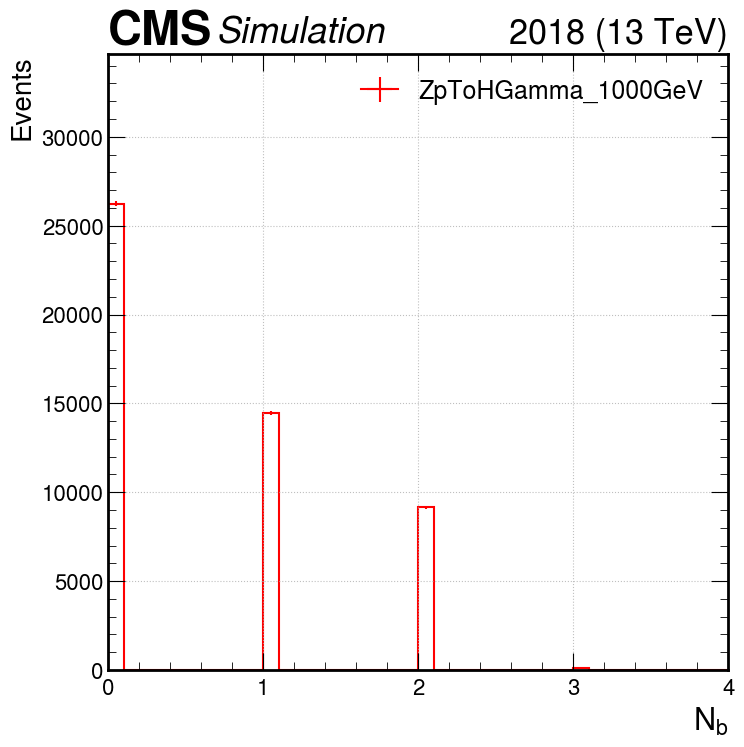

In [60]:
cuts = PackedSelection()
array = {'ZpToHGamma_1000GeV': ak.sum(events.Jet.btagDeepFlavB>0.7100, axis=1)}
plot(array, x_name=r'$N_b$', x_max=4, density=False)

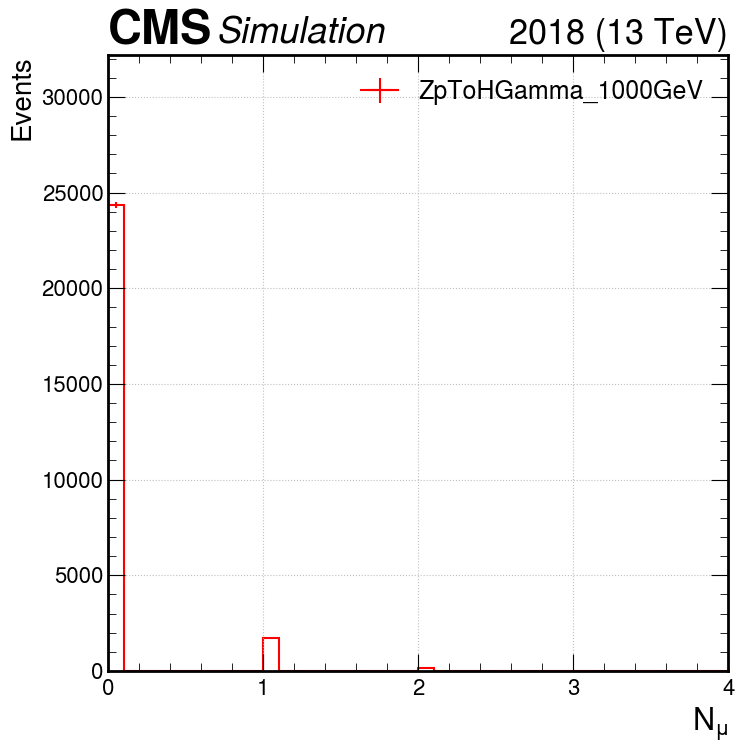

In [61]:
cuts.add(r'$N_b$==0', np.array(array['ZpToHGamma_1000GeV']==0))

raw_muon = events.Muon  # (event, muon)
muon = (  # (event, boolean)
    # high-pT cut-based ID (1 = tracker high pT, 2 = global high pT, which includes tracker high pT)
    (raw_muon.highPtId == 2) &
    (raw_muon.tkRelIso < 0.1) &  # Tracker-based relative isolation dR=0.3 for highPt, trkIso/tunePpt
    (abs(raw_muon.eta) < 2.4) &
    (raw_muon.pt > 20)  # I don't use `muon_corrected_pt` coming from ROOT.RoccoR
)

array = {'ZpToHGamma_1000GeV': ak.sum(muon, axis=1)}
plot(array, cuts={'ZpToHGamma_1000GeV': cuts.all(*cuts.names)}, x_name=r'$N_\mu$', x_max=4, density=False)

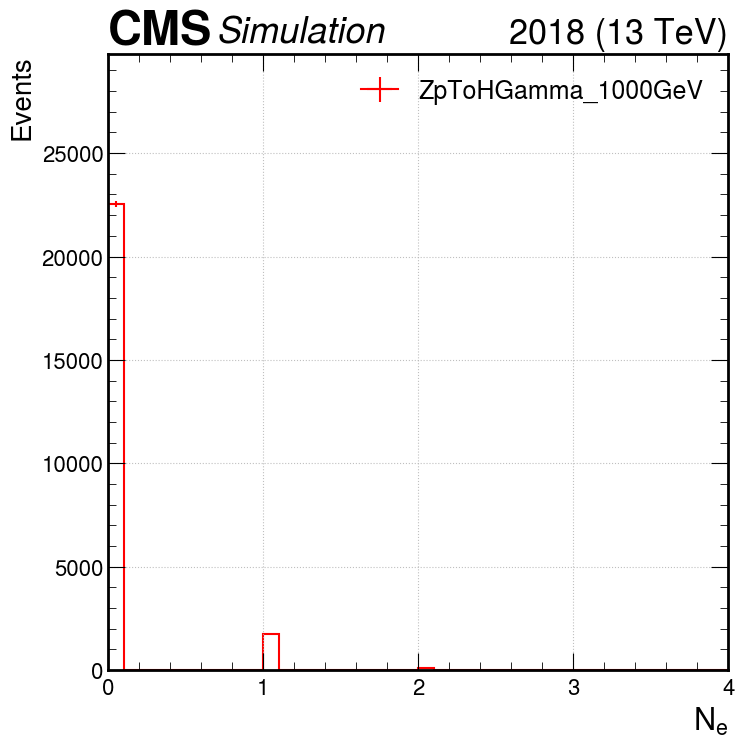

In [62]:
cuts.add(r'$N_\mu$==0', np.array(array['ZpToHGamma_1000GeV']==0))

raw_electron = events.Electron  # (event, electron)
electron = (  # (event, boolean)
    (raw_electron.cutBased_HEEP == True) &  # cut-based HEEP ID
    (abs(raw_electron.eta) < 2.5) &
    (raw_electron.pt > 20)
)

array = {'ZpToHGamma_1000GeV': ak.sum(electron, axis=1)}
plot(array, cuts={'ZpToHGamma_1000GeV': cuts.all(*cuts.names)}, x_name=r'$N_e$', x_max=4, density=False)

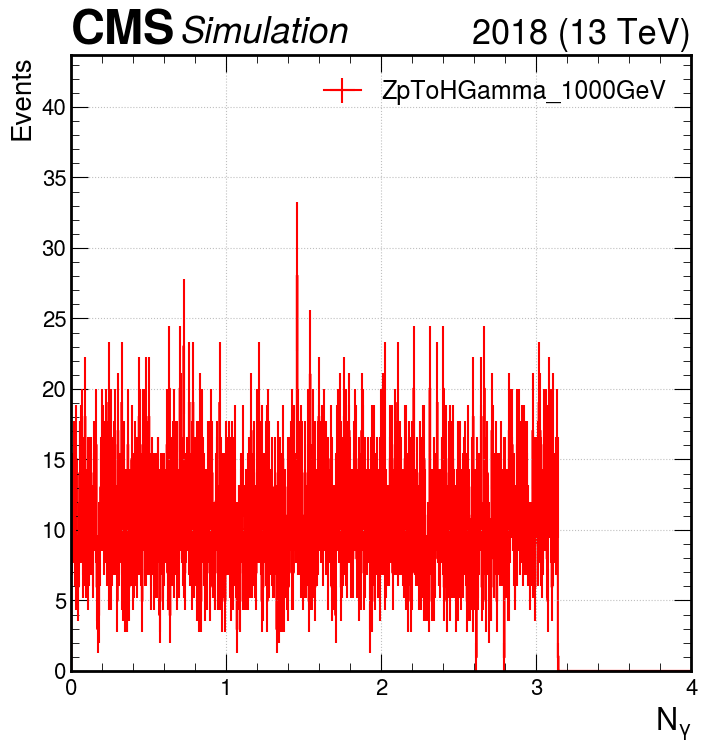

In [63]:
cuts.add(r'$N_e$==0', np.array(array['ZpToHGamma_1000GeV']==0))

raw_photon = events.Photon  # (event, photon), >=1 photon per event
photon = (  # (event, boolean)
    (raw_photon.mvaID_WP90 > 0.2) &
    (raw_photon.pt > 200) &
    (abs(raw_photon.eta) < 2.4)
)

cuts.add(r'$N_\gamma$>=1', np.array(ak.sum(photon, axis=1)==1))
array = {'ZpToHGamma_1000GeV': ak.flatten(events.Photon[photon][cuts.all(*cuts.names)].phi)}
plot(array, x_name=r'$N_\gamma$', x_max=4, bins=1000, density=False)

In [64]:
cuts.add(r'$N_\gamma$>=1', np.array(array['ZpToHGamma_1000GeV']>=1))

raw_AK8jet = events.FatJet  # (event, fatjet), >=1 AK8 jet per event
AK8jet = (  # (event, boolean)
    (raw_AK8jet.msoftdrop > 40) &  # Corrected soft drop mass with PUPPI
    (raw_AK8jet.pt > 250) &
    (abs(raw_AK8jet.eta) < 2.4) &
    (raw_AK8jet.jetId & 2 > 0)
    # Jet ID flags bit1 is loose (always false in 2017 since it does not exist),
    # bit2 is tight, bit3 is tightLepVeto
)

array = {'ZpToHGamma_1000GeV': ak.sum(AK8jet, axis=1)}
plot(array, cuts={'ZpToHGamma_1000GeV': cuts.all(*cuts.names)}, x_name=r'$N_{AK8}$', x_max=4, density=False)

ValueError: New selection '$N_\gamma$>=1' has different shape than existing ones ((17218,) vs. (50000,))

In [ ]:
cuts.add(r'$N_{AK8}$>=1', np.array(array['ZpToHGamma_1000GeV']>=1))

photon = ak.fill_none(photon, cuts.all(*cuts.names))
AK8jet = ak.fill_none(AK8jet, cuts.all(*cuts.names))

In [ ]:
photonArray = events.Photon[photon][cuts.all(*cuts.names)]
AK8jetArray = events.FatJet[AK8jet][cuts.all(*cuts.names)]
photonArray, AK8jetArray

(<PhotonArray [[Photon], [Photon, ... [Photon]] type='9720 * var * photon'>,
 <FatJetArray [[FatJet], [FatJet, ... [FatJet]] type='9720 * var * fatJet'>)

In [ ]:
pj_pair = ak.cartesian({'photon': photonArray, 'jet': AK8jetArray}, axis=1, nested=False)
pj_index_pair = ak.argcartesian({'photon': photonArray, 'jet': AK8jetArray}, axis=1, nested=False)
pj_dr = pj_pair.photon.delta_r(pj_pair.jet)

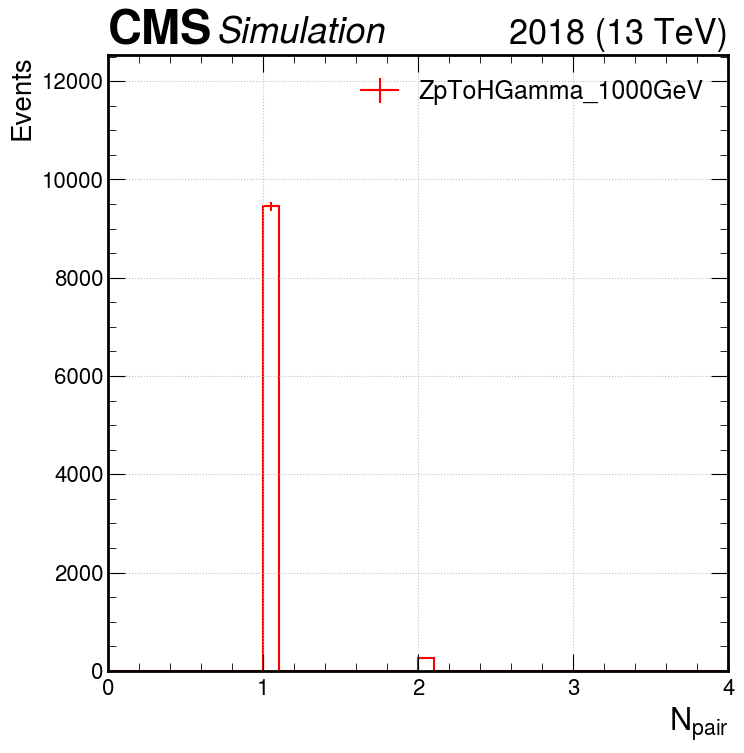

In [ ]:
array={'ZpToHGamma_1000GeV': ak.sum(pj_dr>0, axis=1)}
plot(array, x_name=r'$N_{pair}$', x_max=4, density=False)

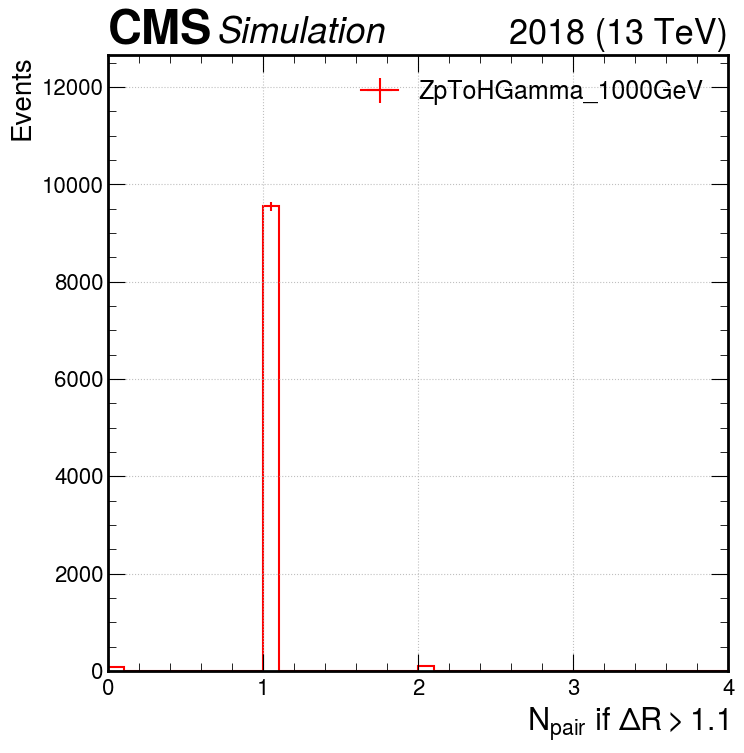

In [ ]:
array={'ZpToHGamma_1000GeV': ak.sum(pj_dr>1.1, axis=1)}
plot(array, x_name=r'$N_{pair}\ if\ \Delta R>1.1 $', x_max=4, density=False)

In [ ]:
events=NanoEventsFactory.from_root(file='/data/pubfs/fudawei/samples/mc/2018/GJets/GJets_HT-40To100_TuneCP5_13TeV-madgraphMLM-pythia8/RunIISummer20UL18NanoAODv9-106X_upgrade2018_realistic_v16_L1v1-v1/NANOAODSIM/DCE1DE49-5A74-FE4F-984A-66BCADE4A60E.root', treepath='Events', schemaclass=NanoAODSchema).events()

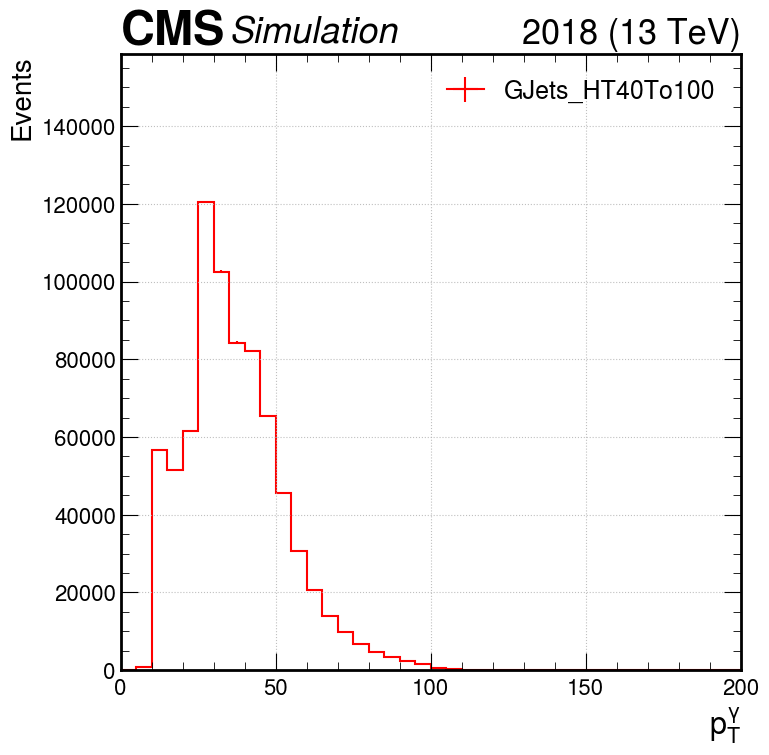

In [ ]:
plot({'GJets_HT40To100': ak.flatten(events.Photon.pt)}, x_name=r'$p_T^{\gamma}$', x_max=200, density=False)

In [ ]:
events.Jet[ak.num(events.Jet)>0].pt

<Array [[63.9, 63.7, 20.1, ... 18, 18, 15.2]] type='635074 * var * float32[param...'>